### 1.Importing Libraries

In [4]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load the crop recommendation dataset from the raw data folder
df = pd.read_csv("../data/raw/crop_recommendation.csv")

# Display the first 5 rows to understand the structure of the dataset
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
# Check number of rows and columns in the dataset
df.shape


(2200, 8)

In [7]:
# Display data types and non-null counts for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [8]:
# Check how many missing (null) values exist in each column
df.isnull().sum()



N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [9]:
# Calculate the percentage of missing values in each column
#If all values are 0 → dataset has NO missing values
#No need for data imputation
(df.isnull().sum() / len(df)) * 100

N              0.0
P              0.0
K              0.0
temperature    0.0
humidity       0.0
ph             0.0
rainfall       0.0
label          0.0
dtype: float64

In [10]:
# Check if duplicate rows exist in the dataset
df.duplicated().sum()


np.int64(0)

In [11]:
# Remove duplicate rows if any are found
df = df.drop_duplicates()


In [12]:
# Generate statistical summary (mean, min, max, etc.)
df.describe()


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [13]:
# Check how many samples exist for each crop
df["label"].value_counts()


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Class distribution and numeric feature exploration

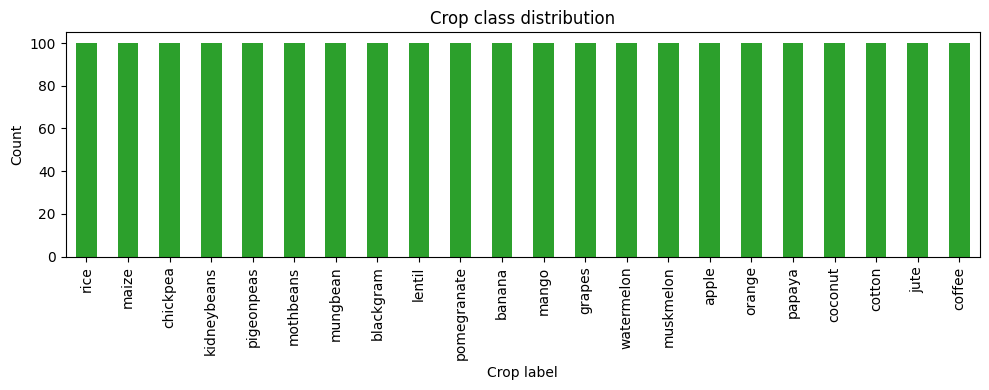

In [14]:
# Bar plot of crop class counts
class_counts = df["label"].value_counts().sort_values(ascending=False)
ax = class_counts.plot(kind="bar", figsize=(10, 4), color="tab:green")
ax.set_ylabel("Count")
ax.set_xlabel("Crop label")
ax.set_title("Crop class distribution")
plt.tight_layout()

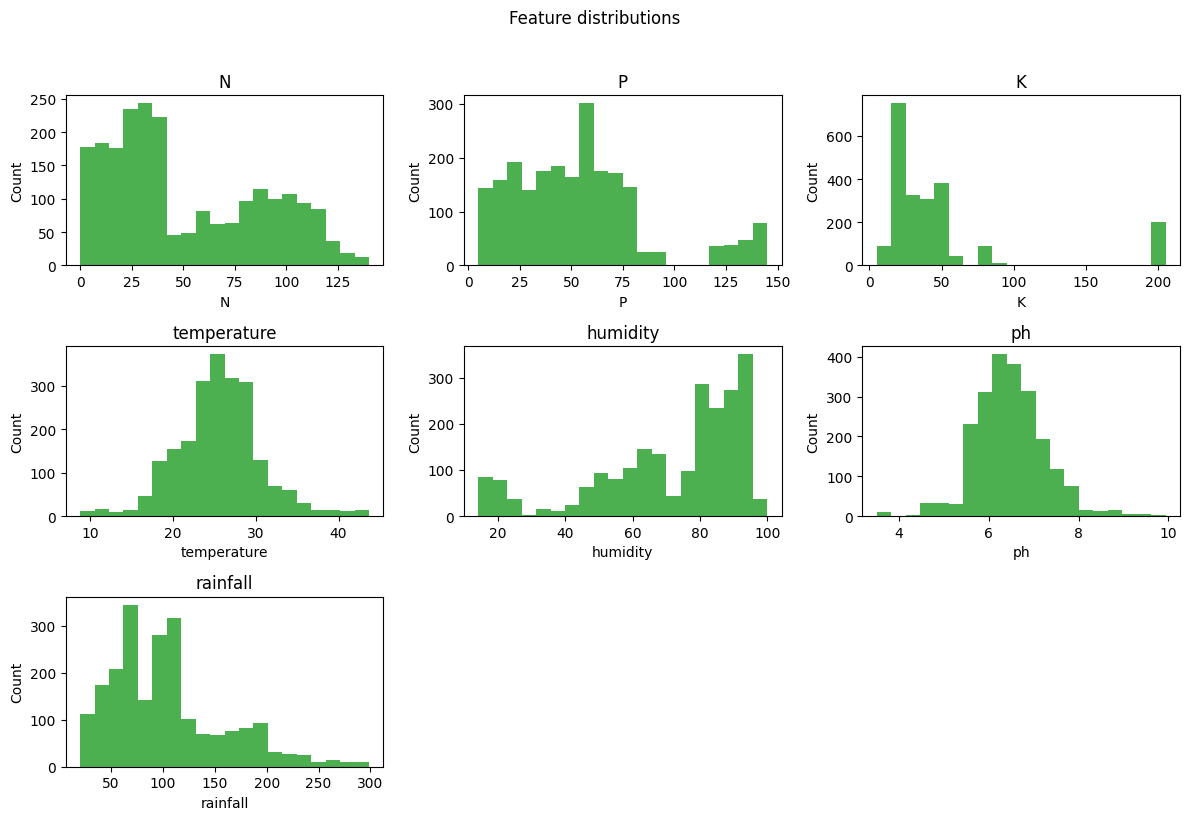

In [7]:
# Histograms for numeric features to inspect distributions/outliers
num_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
axes = df[num_cols].hist(bins=20, figsize=(12, 8), grid=False, color="#4caf50")
for ax, col in zip(axes.flatten(), num_cols):
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()

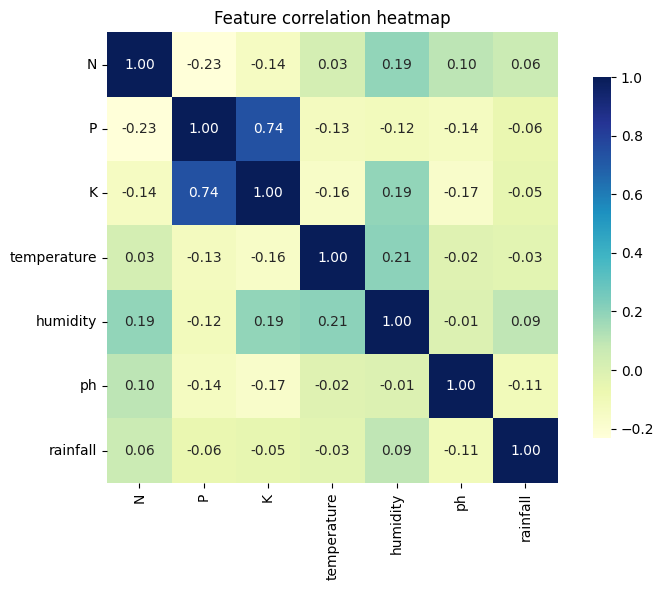

In [16]:
# Correlation heatmap to see relationships between features
import seaborn as sns
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation heatmap")
plt.tight_layout()

In [17]:
# Separate input features (soil and weather conditions)
X = df.drop("label", axis=1)

# Separate target variable (crop name)
y = df["label"]


Encode Crop Labels
 - Crop names converted to numbers
 - Required for machine learning algorithms

In [18]:
# Convert crop names (strings) into numeric labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [19]:
# Split data into training and testing sets
# 80% for training, 20% for testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # keeps class distribution balanced
)


In [20]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Initialize model with 300 trees for better accuracy
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# Train the model on training data
model.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Predict crop labels on test data
y_pred = model.predict(X_test)

# Display accuracy of the model
print("Model Accuracy:", accuracy_score(y_test, y_pred))

# Display precision, recall, and F1-score
print(classification_report(y_test, y_pred))


Model Accuracy: 0.9931818181818182
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00   

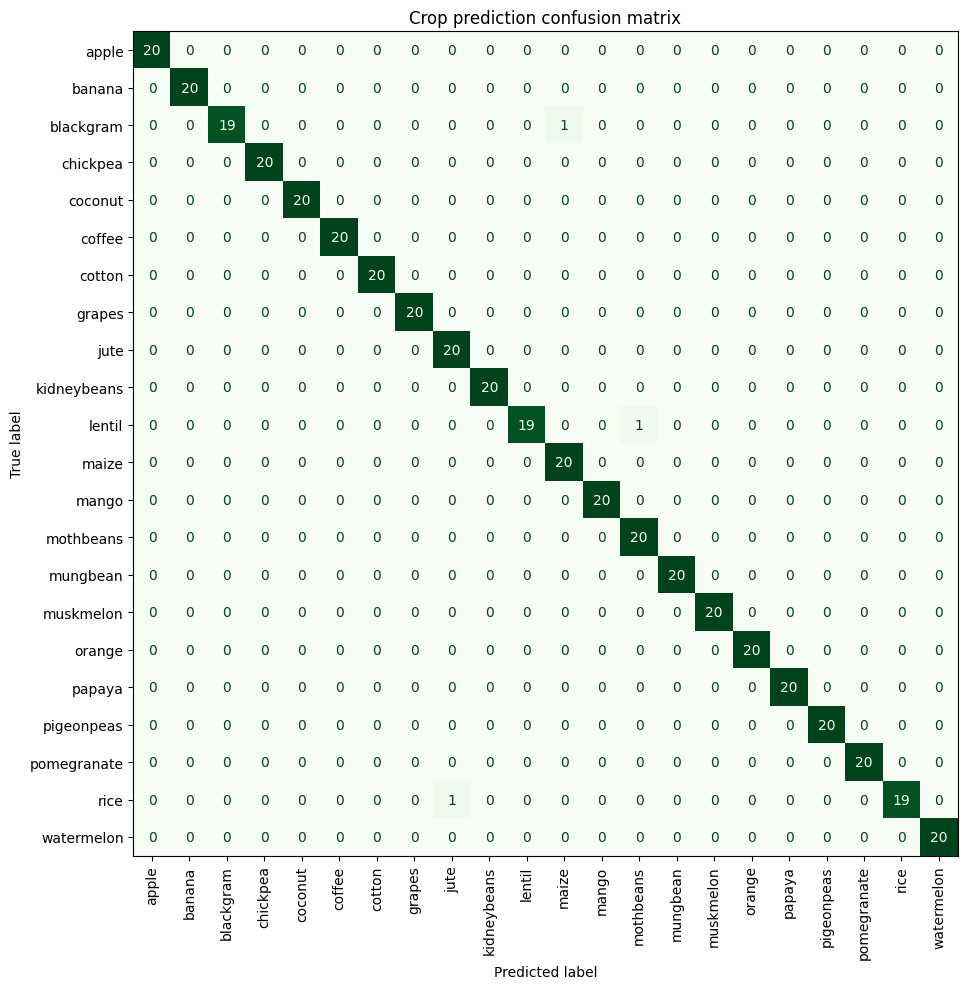

In [22]:
# Confusion matrix to inspect per-class performance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=90, cmap="Greens", colorbar=False)
ax.set_title("Crop prediction confusion matrix")
plt.tight_layout()

In [23]:
# Select a sample input from dataset
sample = X.iloc[0:1]

# Predict crop for the sample input
prediction = model.predict(sample)

# Convert numeric prediction back to crop name
predicted_crop = le.inverse_transform(prediction)

print("Predicted Crop:", predicted_crop[0])
print("Actual Crop:", y.iloc[0])


Predicted Crop: rice
Actual Crop: rice


In [24]:
# Save cleaned dataset as final version
df.to_csv("../data/processed/crop_recommendation_cleaned.csv", index=False)


In [25]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
print(f"CV Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


CV Mean: 0.994 ± 0.003


In [26]:
import joblib
joblib.dump(model, '../models/crop_recommendation_model.pkl')
joblib.dump(le, '../models/crop_label_encoder.pkl')


['../models/crop_label_encoder.pkl']

In [27]:
# Compare test accuracy with cross-validation to check for overfitting
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_test, y_pred)
cv_mean = cv_scores.mean()

print(f"Test Accuracy: {test_acc:.3f}")
print(f"CV Mean Accuracy: {cv_mean:.3f}")
print(f"Difference: {abs(test_acc - cv_mean):.3f}")

if abs(test_acc - cv_mean) < 0.05:
    print("✓ No overfitting - model generalizes well")
else:
    print("⚠ Check for potential overfitting")

Test Accuracy: 0.993
CV Mean Accuracy: 0.994
Difference: 0.001
✓ No overfitting - model generalizes well
